In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as colors
import utils
import h5py
import astropy.constants as cons
from matplotlib.colors import LogNorm
import astropy.units as u
import athena_read as ar
import plot_slice
import tde_unit as tde
import pandas as pd
import k3d
from k3d.colormaps import matplotlib_color_maps
c=cons.c.cgs.value
G=cons.G.cgs.value
h=cons.h.cgs.value
Msun=cons.M_sun.cgs.value
Mbh=3.0e6*Msun
mp=cons.m_p.cgs.value
kB=cons.k_B.cgs.value
v0=0.0005*c 
mu=0.6
r0=2*G*Mbh/c**2


In [2]:
import h5py
import numpy as np
import os

def convert_athdf_doubles_to_floats(input_file, output_file=None):
    """
    Converts all float64 datasets in a .athdf (HDF5) file to float32 and saves to a new file.

    Parameters:
        input_file (str): Path to the original .athdf file.
        output_file (str, optional): Path to the output file. If None, appends '_float32' to the input filename.
    """

    if output_file is None:
        base, ext = os.path.splitext(input_file)
        output_file = f"{base}_float32{ext}"

    def copy_attrs(src, dst):
        for key, val in src.attrs.items():
            dst.attrs[key] = val

    def process_group(src_group, dst_group):
        for name, item in src_group.items():
            if isinstance(item, h5py.Dataset):
                data = item[()]  # Read the data
                if data.dtype == np.float64:
                    data = data.astype(np.float32)
                dst_dset = dst_group.create_dataset(name, data=data, compression=item.compression)
                copy_attrs(item, dst_dset)
            elif isinstance(item, h5py.Group):
                new_group = dst_group.create_group(name)
                copy_attrs(item, new_group)
                process_group(item, new_group)

    with h5py.File(input_file, 'r') as src_file:
        with h5py.File(output_file, 'w') as dst_file:
            copy_attrs(src_file, dst_file)
            process_group(src_file, dst_file)

    print(f"Conversion complete: {output_file}")


In [3]:
convert_athdf_doubles_to_floats("../data/input.cbdisk.out1.01637.athdf")

Conversion complete: ../data/input.cbdisk.out1.01637_float32.athdf


In [4]:
with h5py.File("../data/input.cbdisk.out1.01637.athdf", "r") as f1, h5py.File("../data/input.cbdisk.out1.01637_float32.athdf", "r") as f2:
    var = "prim"  # Example dataset path
    d1 = f1[var][1][()]
    d2 = f2[var][1][()]
    print("Max abs diff:", np.max(np.abs(d1 - d2.astype(np.float64))))
    print("Max rel diff:", np.max(np.abs((d1 - d2.astype(np.float64)) / (d1 + 1e-12))))


Max abs diff: 1.1013657524697704e-16
Max rel diff: 5.896126580535833e-08


In [12]:
ogfile = h5py.File("../data/input.cbdisk.out1.01637.athdf", "r")
newfile = h5py.File("../data/input.cbdisk.out1.01637_float32.athdf", "r")
print(ogfile["prim"].shape)
print(newfile["prim"].shape)

(25, 4016, 16, 16, 16)
(25, 4016, 16, 16, 16)


In [16]:
print(list(ogfile.keys()))

['B', 'Levels', 'LogicalLocations', 'prim', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']


In [17]:
ogfile["prim"][24][3,8,9,15]

0.39005013035169833

In [18]:
newfile["prim"][24][3,8,9,15]

0.39005014

In [33]:
ogfile["prim"]

<HDF5 dataset "prim": shape (25, 4016, 16, 16, 16), type "<f8">

In [32]:
plt.rcParams["figure.figsize"] = (6,6)
plt.rcParams["figure.dpi"] = 100

In [33]:
temperatures = np.loadtxt('../debugOutput/findHighTemp.csv')
print(np.max(temperatures))

1002210000000.0


In [7]:
tdeFile = h5py.File('../data/input.cbdisk.out1.01637_float32.athdf', 'r')
print(list(tdeFile.keys()))

['B', 'Levels', 'LogicalLocations', 'prim', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']


In [10]:
print(np.array(tdeFile['x1f'])[4010:4015,:])

[[ 312.1581   327.7348   344.1682   361.50546  379.79623  399.09305
   419.45114  440.92896  463.58804  487.49338  512.7135   539.32074
   567.3914   597.0059   628.24927  661.21094  695.98553]
 [ 695.98553  732.6727   771.37775  812.2115   855.29114  900.7402
   948.68884  999.2747  1052.6428  1108.9462  1168.3462  1231.0133
  1297.127   1366.877   1440.4633  1518.0967  1600.     ]
 [ 312.1581   327.7348   344.1682   361.50546  379.79623  399.09305
   419.45114  440.92896  463.58804  487.49338  512.7135   539.32074
   567.3914   597.0059   628.24927  661.21094  695.98553]
 [ 695.98553  732.6727   771.37775  812.2115   855.29114  900.7402
   948.68884  999.2747  1052.6428  1108.9462  1168.3462  1231.0133
  1297.127   1366.877   1440.4633  1518.0967  1600.     ]
 [ 312.1581   327.7348   344.1682   361.50546  379.79623  399.09305
   419.45114  440.92896  463.58804  487.49338  512.7135   539.32074
   567.3914   597.0059   628.24927  661.21094  695.98553]]


In [16]:
print(tdeFile['Levels'])
print(tdeFile['LogicalLocations'])
print(tdeFile['B'])
print(tdeFile['x1f'])
print(tdeFile['prim'])

<HDF5 dataset "Levels": shape (4016,), type ">i4">
<HDF5 dataset "LogicalLocations": shape (4016, 3), type ">i8">
<HDF5 dataset "B": shape (3, 4016, 16, 16, 16), type "<f4">
<HDF5 dataset "x1f": shape (4016, 17), type "<f4">
<HDF5 dataset "prim": shape (25, 4016, 16, 16, 16), type "<f4">


In [4]:
tdeFile = h5py.File('../data/tdestream.out1.01335.athdf', 'r')
print(list(tdeFile.keys()))

['B', 'Levels', 'LogicalLocations', 'prim', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']


In [5]:
print(tdeFile['Levels'])
print(tdeFile['LogicalLocations'])
print(tdeFile['B'])
print(tdeFile['x1f'])
print(tdeFile['prim'])

<HDF5 dataset "Levels": shape (88355,), type ">i4">
<HDF5 dataset "LogicalLocations": shape (88355, 3), type ">i8">
<HDF5 dataset "B": shape (3, 88355, 8, 4, 8), type "<f4">
<HDF5 dataset "x1f": shape (88355, 9), type "<f4">
<HDF5 dataset "prim": shape (25, 88355, 8, 4, 8), type "<f4">


In [6]:
arguments = {'data_file': '../data/tdestream.out1.01335.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)

(512, 1024)


In [7]:
arguments = {'data_file': '../data/tdestream.out1.01335.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)

(512, 1024)


In [8]:
rho0=1e-8
kT = mu*mp*((v0**2)*rho0*press)/(rho*rho0)
T = kT/kB

In [22]:
print(np.max(T))

86952140.0


slice location 0.5 yielded max T around 8.97e9

slice location 0.0 yielded max T around 5.66e11

for tdestream.out1.01335.athdf

In [10]:
T

array([[330193.8  , 330193.8  , 330193.8  , ...,  30123.338,  30123.338,
         30123.338],
       [330193.8  , 330193.8  , 330193.8  , ...,  30123.338,  30123.338,
         30123.338],
       [330193.8  , 330193.8  , 330193.8  , ...,  30123.338,  30123.338,
         30123.338],
       ...,
       [403645.8  , 403645.8  , 403645.8  , ...,  29436.215,  29436.215,
         29436.215],
       [403645.8  , 403645.8  , 403645.8  , ...,  29436.215,  29436.215,
         29436.215],
       [403645.8  , 403645.8  , 403645.8  , ...,  29436.215,  29436.215,
         29436.215]], dtype=float32)

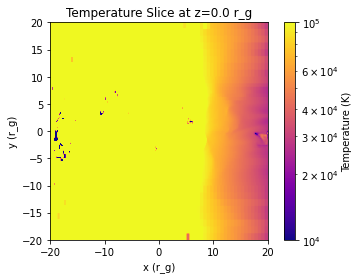

In [11]:
plt.imshow(T, origin='lower', extent=[-20,20,-20,20], norm=LogNorm(vmin=1e4, vmax=1e5), cmap='plasma')
plt.colorbar(label='Temperature (K)')
plt.xlabel('x (r_g)')
plt.ylabel('y (r_g)')
plt.title('Temperature Slice at z=0.0 r_g')
plt.show()

In [37]:
tdeFile = h5py.File('../data/tdestream.out1.00600.athdf', 'r')
print(list(tdeFile.keys()))
arguments = {'data_file': '../data/tdestream.out1.00600.athdf', 'quantity': 'press', 'output_file': './plots/pressPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
press = plot_slice.getDataSlice(**arguments)
print(press.shape)
arguments = {'data_file': '../data/tdestream.out1.00600.athdf', 'quantity': 'rho', 'output_file': './plots/rhoPlot.png', 'direction': 3, 'slice_location': 0.0, 'average': False, 'sum': False, 'level': None, 'x_min': None, 'x_max': None, 'y_min': None, 'y_max': None, 'fill': False, 'colormap': None, 'vmin': None, 'vmax': None, 'logc': False, 'stream': None, 'stream_average': False, 'stream_density': 1.0, 'num_ghost': 0}
rho = plot_slice.getDataSlice(**arguments)
print(rho.shape)
rho0=1e-8
kT = mu*mp*((v0**2)*rho0*press)/(rho*rho0)
T = kT/kB

['B', 'Levels', 'LogicalLocations', 'prim', 'x1f', 'x1v', 'x2f', 'x2v', 'x3f', 'x3v']
(512, 1024)
(512, 1024)


In [39]:
np.average((rho*1e-8 / (mu * mp))**2)

1.2328568e+28

In [42]:
-np.average((rho*1e-8 / (mu * mp))**2)*3.55e-69*(G*Mbh/c**2)

-1.9387975349024597e-29

In [43]:
"{:.2E}".format(1-np.exp(-np.average((rho*1e-8 / (mu * mp))**2)*3.55e-69*10*(G*Mbh/c**2)))

'0.00E+00'

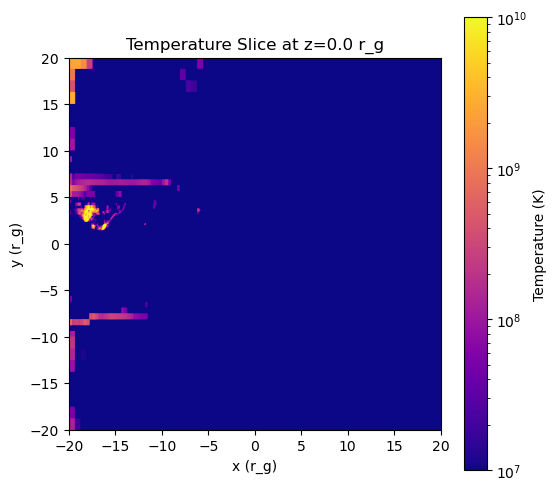

In [30]:
plt.imshow(T, origin='lower', extent=[-20,20,-20,20], norm=LogNorm(vmin=1e7, vmax=1e10), cmap='plasma')
plt.colorbar(label='Temperature (K)')
plt.xlabel('x (r_g)')
plt.ylabel('y (r_g)')
plt.title('Temperature Slice at z=0.0 r_g')
plt.show()

rayleigh jeans approx


In [44]:
a = 0.018*np.average(T**(-3/2))*np.average((rho*1e-8 / (mu * mp))**2)*1e-16
j = 6.8e-38*np.average((rho*1e-8 / (mu * mp))**2)*np.average(T**(-3/2))*1e-32

In [47]:
j/a

3.777777777777778e-52